# TSARA — a value is not an instant

**Phase 3.5 walkthrough.** Run top to bottom. Every number and figure below is
produced by the package itself from data manufactured in this notebook. No real
measurement is read anywhere and nothing needs mounting to run it.

The archive TSARA was built for is not silent here, though. This phase exists
because of what that archive turned out to contain, and where a decision was
settled by measuring real files the measurement is quoted in the prose with a
pointer to `docs/METHODS.md` §10, which holds the tables.

---

## The finding

TSARA's first three phases treated every timestamp as an instant: a row said
1900 ppb *at* 14:03:00. Most of the real archive does not mean that. The whole
stationary suite publishes one-minute **means**. Canisters integrate for about
fifteen seconds and then sit idle for minutes. One-second ICARTT rows are
start-labelled by specification, so their timestamp is not even the middle of
the thing they describe.

Reading a 60 s mean as an instant invents 59 seconds of resolution the
instrument never had. It is the same sin as interpolating, stated more
generally, and it leads to a specific, quantifiable error that this notebook
measures below: pairing a fast stream against those means, assuming the
timestamp sits in the middle, pairs each mean with the wrong half-minute.

So a value carries the **interval of air it describes**, and the rest of this
notebook is what that costs and what it buys.

In [1]:
import logging
import tempfile
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tsara import setup_logging
from tsara.config.loader import load_manifest
from tsara.config.manifest import Manifest
from tsara.core.support import CellBounds, TsaraSupportError, bin_onto_cells, check_bounds_intact
from tsara.ingest import ingest_campaign
from tsara.synthetic import generate
from tsara.synthetic.config import SyntheticConfig
from tsara.synthetic.export import export_raw

# --- figure style (identical to notebooks 01 and 02) -----------------------
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.size": 9.5,
        "lines.linewidth": 1.4,
        "figure.dpi": 110,
    }
)


def finish(
    ax, title=None, sub=None, ylab=None, xlab=None, legend=False, grid_axis="y", loc="upper right"
):
    """Apply the shared chrome: left-aligned title, muted subtitle, hairline grid."""
    if title:
        ax.set_title(title, pad=19 if sub else 8)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=8.8, color=MUTED, va="bottom")
    if ylab:
        ax.set_ylabel(ylab)
    if xlab:
        ax.set_xlabel(xlab)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    if legend:
        ax.legend(loc=loc)


def hhmm(ax, fmt="%H:%M"):
    """Label the x axis as clock time; the date belongs in the title."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def bounds_of(stream):
    """Cell start and stop of a stream, as datetime64 arrays for plotting."""
    edges = stream["time_bnds"].values
    return edges[:, 0], edges[:, 1]


def cells_of(stream):
    """Return a stream's cells as the CellBounds the binning primitive takes."""
    edges = stream["time_bnds"].values
    return CellBounds(
        start_ns=edges[:, 0].astype("datetime64[ns]").astype("int64"),
        stop_ns=edges[:, 1].astype("datetime64[ns]").astype("int64"),
    )


# Every file this notebook writes goes here and is cleaned up when the kernel
# exits. Paths are shown with this prefix replaced, so the output does not
# depend on which machine ran it.
_work = tempfile.TemporaryDirectory()
WORK = Path(_work.name)


def show(text):
    """Print text with the scratch directory replaced by a stable placeholder."""
    print(str(text).replace(str(WORK), "<work>"))


def scrub_paths_from_logs(logger):
    """Give log records the same treatment `show` gives printed text.

    The filter goes on the **handler**, not on the logger: a record logged to
    `tsara.ingest.support` propagates up to the `tsara` logger's handlers, but
    filters attached to the `tsara` logger itself are never consulted for it.
    """

    def rewrite(record):
        if isinstance(record.msg, str):
            record.msg = record.msg.replace(str(WORK), "<work>")
        if isinstance(record.args, tuple):
            record.args = tuple(
                str(a).replace(str(WORK), "<work>") if str(WORK) in str(a) else a
                for a in record.args
            )
        return True

    for handler in logger.handlers:
        handler.addFilter(rewrite)
    return logger


print("ready")

ready


---
## 1. The vocabulary

Four words carry the whole phase, and they are worth separating before any data
appears.

- A **cell** is one row: a value plus the interval of air it describes.
- Its **support** is that interval; its **width** is how long it lasts.
- Its **label** says which instant inside the cell the file's timestamp names —
  the start, the middle, or the end.
- Its **method** says whether the value is an average over the whole cell or a
  single sample taken somewhere inside it.

None of this is TSARA's invention. The Climate and Forecast conventions already
have the vocabulary: a `time_bnds` variable holding each cell's start and stop,
and a `cell_methods` attribute saying `time: mean` or `time: point`. TSARA
writes exactly that, so its files read correctly in any CF-aware tool.

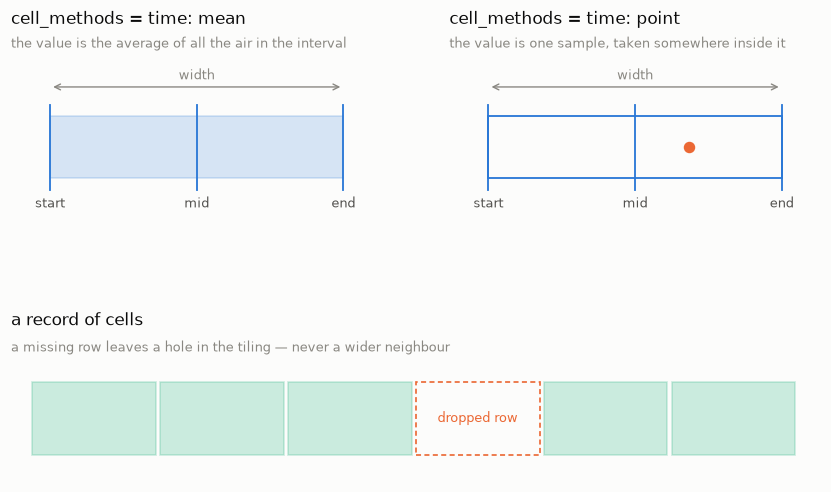

In [2]:
fig = plt.figure(figsize=(9.5, 5.0))
gs = fig.add_gridspec(2, 2, height_ratios=[1.35, 1.0], hspace=0.95, wspace=0.18)


def draw_cell(ax, *, filled, dot):
    """One cell: its boundaries, its three nameable instants, its width."""
    ax.add_patch(
        plt.Rectangle(
            (0, 0.30),
            60,
            0.42,
            facecolor=C1 if filled else "none",
            alpha=0.18 if filled else 1.0,
            edgecolor=C1,
            lw=1.2,
        )
    )
    for x, name in [(0, "start"), (30, "mid"), (60, "end")]:
        ax.plot([x, x], [0.22, 0.80], color=C1, lw=1.2)
        ax.text(x, 0.08, name, ha="center", va="bottom", fontsize=8.8, color=INK2)
    ax.annotate(
        "",
        xy=(0, 0.92),
        xytext=(60, 0.92),
        arrowprops={"arrowstyle": "<->", "color": MUTED, "lw": 0.9},
    )
    ax.text(30, 0.95, "width", ha="center", va="bottom", fontsize=8.8, color=MUTED)
    if dot:
        ax.plot([41], [0.51], "o", color=C2, ms=6.5)
    ax.set_xlim(-8, 68)
    ax.set_ylim(0, 1.12)
    ax.axis("off")


ax = fig.add_subplot(gs[0, 0])
draw_cell(ax, filled=True, dot=False)
ax.set_title("cell_methods = time: mean", pad=22)
ax.text(
    0,
    1.06,
    "the value is the average of all the air in the interval",
    transform=ax.transAxes,
    fontsize=8.8,
    color=MUTED,
)

ax = fig.add_subplot(gs[0, 1])
draw_cell(ax, filled=False, dot=True)
ax.set_title("cell_methods = time: point", pad=22)
ax.text(
    0,
    1.06,
    "the value is one sample, taken somewhere inside it",
    transform=ax.transAxes,
    fontsize=8.8,
    color=MUTED,
)

ax = fig.add_subplot(gs[1, :])
for k in range(6):
    ax.add_patch(
        plt.Rectangle(
            (k * 60, 0.30),
            58,
            0.42,
            facecolor="none" if k == 3 else C3,
            alpha=1.0 if k == 3 else 0.22,
            edgecolor=C2 if k == 3 else C3,
            lw=1.1,
            ls=(0, (3, 2)) if k == 3 else "-",
        )
    )
ax.text(3 * 60 + 29, 0.51, "dropped row", ha="center", va="center", fontsize=8.8, color=C2)
ax.set_xlim(-10, 370)
ax.set_ylim(0.15, 0.85)
ax.axis("off")
ax.set_title("a record of cells", pad=22)
ax.text(
    0,
    1.06,
    "a missing row leaves a hole in the tiling — never a wider neighbour",
    transform=ax.transAxes,
    fontsize=8.8,
    color=MUTED,
)
plt.show()

That last panel is a decision, not a drawing convention. When a manifest does
not declare a width, TSARA infers one from the file's own median sampling
interval and gives **every row that same width**. The obvious alternative —
stretch each cell to reach the next row — was rejected on measurement: across
the whole archive it would have produced a single cell **23.3 days** wide, and
99% of intervals are jitter around one cadence anyway (`METHODS.md` §10.5).

A dropped row is missing information, not a longer measurement.

---
## 2. A campaign at three supports

One source, seen by three instruments that disagree about what a row means.
Everything else about them is deliberately identical, so any difference below
comes from the support and nothing else.

| instrument | rate | width | method | the real thing it stands for |
|---|---|---|---|---|
| `fast` | 1 s | 1 s | point | a laser analyzer publishing a reading per second |
| `minute` | 60 s | 60 s | mean | the stationary suite: one-minute averages, start-labelled |
| `canister` | 90 s | 15 s | mean | a whole-air sampler that fills for 15 s and then waits |

The generator manufactures a `mean` instrument honestly: it renders the truth
on a fine grid *inside* each cell and averages it, rather than evaluating once
and calling the result an average. That is what makes a sharp plume come out
diluted, exactly as a real one-minute mean would record it.

In [3]:
SPEC = {
    "name": "support_demo",
    "seed": 7,
    "start": "2026-06-15T14:00:00Z",
    "duration": "1h",
    "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
    # The air, described once. Every instrument below samples this one
    # methane, so any difference between their records is their support and
    # their own noise -- never a different gas.
    "atmosphere": {
        "fields": {
            "ch4": {
                "background": {"kind": "parametric", "offset": 1900.0},
                "role": "gas",
                "units": "ppb",
            }
        },
        "sources": {
            "well_pad": {
                "rate_per_hour": 26.0,
                "reference_species": "ch4",
                # Sharp: about 20 s wide, so a 60 s cell has something to dilute.
                "shape": {"kind": "emg", "sigma": "6s", "tau": "12s"},
                "amplitude": {"kind": "lognormal", "median": 300.0, "sigma_log": 0.3},
            }
        },
    },
    "instruments": {
        # A point sampler: one reading per second, cell centred on it.
        "fast": {
            "native_rate": "1s",
            "support": {"method": "point", "label": "mid"},
            "measures": {"ch4": {"uncertainty": {"random": {"absolute": 1.5}}}},
        },
        # The shape of the whole stationary suite: 60 s means whose timestamp
        # names the START of the minute, which is the ICARTT convention. Its
        # record of the methane gets a name of its own, so the three streams
        # stay easy to tell apart when they are joined later.
        "minute": {
            "native_rate": "60s",
            "support": {"method": "mean", "label": "start"},
            "measures": {
                "ch4": {"name": "minute_ch4", "uncertainty": {"random": {"absolute": 0.4}}}
            },
        },
        # A duty cycle: `width` shorter than the rate is what makes a canister
        # a canister rather than a slow analyzer.
        "canister": {
            "native_rate": "90s",
            "support": {"method": "mean", "label": "start", "width": "15s"},
            "measures": {"ch4": {"name": "can_ch4", "uncertainty": {"random": {"absolute": 0.2}}}},
        },
    },
}

data = generate(SyntheticConfig.model_validate(SPEC))
fast, minute, can = data.streams["fast"], data.streams["minute"], data.streams["canister"]

for name, stream in data.streams.items():
    edges = stream["time_bnds"].values
    width = (edges[:, 1] - edges[:, 0]).astype("timedelta64[ms]").astype(float) / 1000.0
    step = np.diff(stream["time"].values).astype("timedelta64[ms]").astype(float) / 1000.0
    species = next(v for v in stream.data_vars if not v.startswith(("truth_", "sigma_")))
    print(
        f"{name:9} {stream.sizes['time']:>5} cells   width {width.min():6.2f} s   "
        f"spacing {np.median(step):6.2f} s   {stream[species].attrs['cell_methods']}"
    )

fast       3600 cells   width   1.00 s   spacing   1.00 s   time: point
minute       60 cells   width  60.00 s   spacing  60.00 s   time: mean
canister     40 cells   width  15.00 s   spacing  90.00 s   time: mean


Widths are read off the cells rather than assumed: the canister's are 15 s wide
and 90 s apart, so five sixths of its record belongs to no cell at all. That is
a duty cycle, and it is a different thing from a slow instrument.

Now pick the busiest six minutes of the hour, from the answer key rather than by
guessing an offset, and look at the same air on two of those clocks.

window 14:25:04.449241 - 14:31:04.449241, containing 7 events


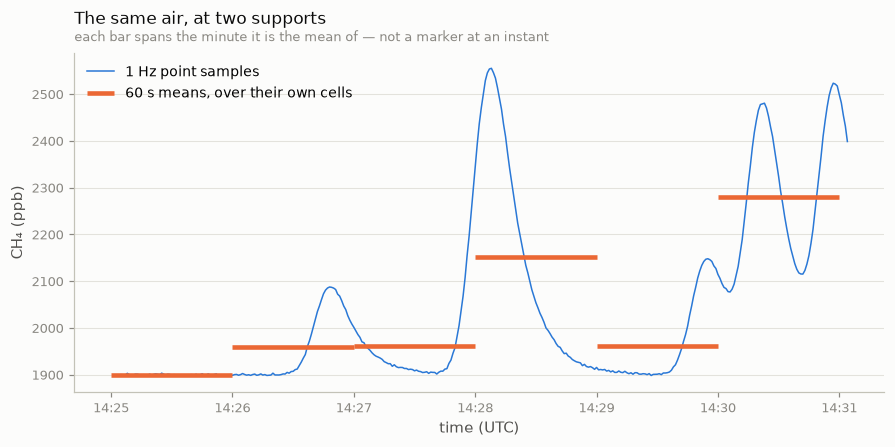

tallest 1 Hz sample in the window :  2555.2 ppb
tallest 60 s mean  in the window :  2279.9 ppb
the minute instrument cannot see  :   275.3 ppb of that plume


In [4]:
events = data.ground_truth.to_frame()
peaks = events[events["species"] == "ch4"].sort_values("peak_time")
busiest = max(
    peaks["peak_time"],
    key=lambda t: (
        (peaks["peak_time"] >= t - pd.Timedelta("3min"))
        & (peaks["peak_time"] <= t + pd.Timedelta("3min"))
    ).sum(),
)
WINDOW = (busiest - pd.Timedelta("3min"), busiest + pd.Timedelta("3min"))
inside = ((peaks["peak_time"] >= WINDOW[0]) & (peaks["peak_time"] <= WINDOW[1])).sum()
print(f"window {WINDOW[0].time()} - {WINDOW[1].time()}, containing {inside} events")


def clip(stream, var):
    """Return the window's worth of one stream, with its cells."""
    sel = stream.sel(time=slice(*WINDOW))
    return sel["time"].values, sel[var].values, sel


t_fast, v_fast, _ = clip(fast, "ch4")
t_min, v_min, min_win = clip(minute, "minute_ch4")
min_start, min_stop = bounds_of(min_win)

fig, ax = plt.subplots(figsize=(9.5, 4.0))
ax.plot(t_fast, v_fast, color=C1, lw=1.0, label="1 Hz point samples")
ax.hlines(v_min, min_start, min_stop, color=C2, lw=3.0, label="60 s means, over their own cells")
finish(
    ax,
    "The same air, at two supports",
    "each bar spans the minute it is the mean of — not a marker at an instant",
    "CH₄ (ppb)",
    "time (UTC)",
    legend=True,
    loc="upper left",
)
hhmm(ax)
plt.show()

peak_fast = float(np.nanmax(v_fast))
peak_min = float(np.nanmax(v_min))
print(f"tallest 1 Hz sample in the window : {peak_fast:7.1f} ppb")
print(f"tallest 60 s mean  in the window : {peak_min:7.1f} ppb")
print(f"the minute instrument cannot see  : {peak_fast - peak_min:7.1f} ppb of that plume")

Drawing the means as **bars rather than markers** is the whole point of the
figure. A marker at the middle of each minute would invite the eye to read a
curve through them, and there is no curve: there are sixty-second averages, and
the instrument has nothing to say about what happened inside one.

The dilution is not an error. It is what a one-minute mean *is*, and the answer
key records it as `sampled_peak_amplitude` — the largest value the instrument
could possibly have seen. A detector cannot be faulted for missing the rest.

---
## 3. What a missing label costs

Both instruments above are honest about their supports because the generator
declared them. The question is what happens when a file does not.

TSARA's fallback for an unknown label is to **centre** the cell on the
timestamp, which is the least-wrong guess: it is never more than half a cell
out, whereas assuming `start` and being wrong is a whole cell out. On the 60 s
suite that is a 30 s error, and here is what it looks like.

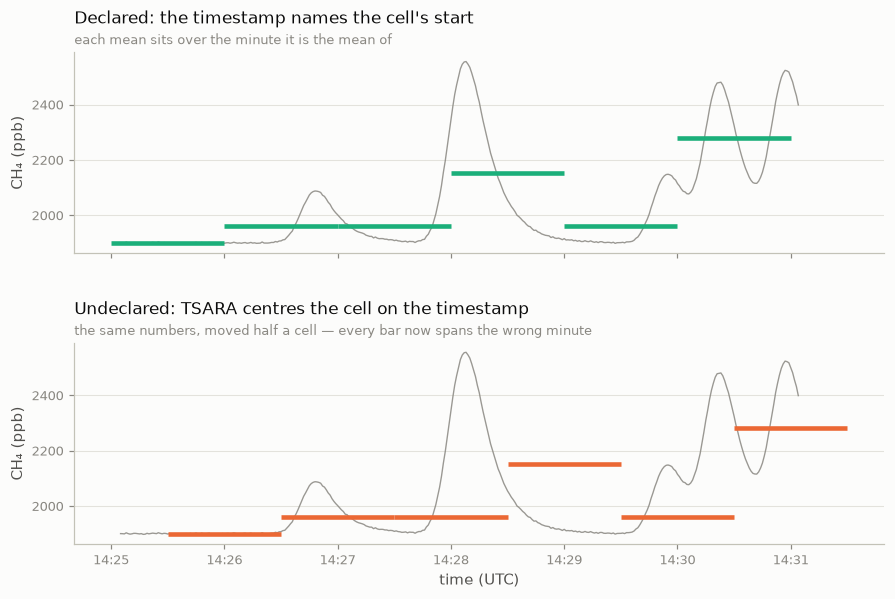

In [5]:
half_cell = np.timedelta64(30, "s")
fig, axes = plt.subplots(
    2, 1, figsize=(9.5, 5.8), sharex=True, sharey=True, gridspec_kw={"hspace": 0.45}
)
panels = [
    (
        np.timedelta64(0, "s"),
        C3,
        "Declared: the timestamp names the cell's start",
        "each mean sits over the minute it is the mean of",
    ),
    (
        half_cell,
        C2,
        "Undeclared: TSARA centres the cell on the timestamp",
        "the same numbers, moved half a cell — every bar now spans the wrong minute",
    ),
]
for ax, (shift, colour, title, sub) in zip(axes, panels, strict=True):
    ax.plot(t_fast, v_fast, color=MUTED, lw=0.9, alpha=0.85)
    ax.hlines(v_min, min_start + shift, min_stop + shift, color=colour, lw=3.0)
    finish(ax, title, sub, "CH₄ (ppb)")
finish(axes[1], None, None, None, "time (UTC)")
hhmm(axes[1])
plt.show()

Look at the tall plume in the middle. In the top panel the bar that contains it
sits over it; in the bottom panel that same number has been attributed to the
following half-minute, where the air was clean.

Seconds are the wrong unit for that error, though. The question a scientist
actually asks is how many parts per billion it costs, and the fast stream can
answer it: average the 1 Hz record over each placement of the cells and compare
with the number the minute instrument actually published.

In [6]:
setup_logging(logging.WARNING)
scrub_paths_from_logs(logging.getLogger("tsara"))

declared_manifest = export_raw(data, WORK / "declared", support_declaration="declared")
undeclared_manifest = export_raw(data, WORK / "undeclared", support_declaration="none")
s_declared = ingest_campaign(load_manifest(declared_manifest))["minute"]
s_undeclared = ingest_campaign(load_manifest(undeclared_manifest))["minute"]

shift = s_undeclared["time"].values - s_declared["time"].values
moved = shift.astype("timedelta64[s]").astype(float)
print(f"every timestamp moves by {np.unique(moved)[0]:.0f} s between the two readings")

fast_cells = cells_of(fast)
published = s_declared["minute_ch4"].values
onto_declared = bin_onto_cells(fast_cells, fast["ch4"].values, cells_of(s_declared))
onto_assumed = bin_onto_cells(fast_cells, fast["ch4"].values, cells_of(s_undeclared))
right = np.abs(onto_declared.values - published)
wrong = np.abs(onto_assumed.values - published)

print()
print("1 Hz average over the DECLARED cells, against the published mean:")
print(f"   median |difference| {np.nanmedian(right):7.2f} ppb   worst {np.nanmax(right):7.1f} ppb")
print("1 Hz average over the ASSUMED cells, against the published mean:")
print(f"   median |difference| {np.nanmedian(wrong):7.2f} ppb   worst {np.nanmax(wrong):7.1f} ppb")

every timestamp moves by -30 s between the two readings

1 Hz average over the DECLARED cells, against the published mean:
   median |difference|    0.34 ppb   worst     1.1 ppb
1 Hz average over the ASSUMED cells, against the published mean:
   median |difference|   15.11 ppb   worst   182.7 ppb


That is the phase in one number. The declared placement recovers the published
minute mean to a few tenths of a ppb — the residual is the two instruments'
independent noise, nothing more. The assumed placement is wrong by more than ten ppb
typically and by well over a hundred at worst, on data where the enhancements
themselves are a few hundred ppb.

The error is not random, either. It is a half-minute shift, so it biases every
pairing in the same direction, and no amount of averaging removes it.

This is why TSARA reports the label it used and where it learned it, rather
than quietly picking one. On the real archive, 700 of the 1122 ICARTT files
justify a `start` label from their own independent-variable name and 402
justify nothing at all (`METHODS.md` §10.6) — so this is the common case, not
the exotic one.

---
## 4. A duty-cycled sampler is not a sparse one

The canister makes the difference between *rate* and *width* concrete. It
produces a value every 90 seconds, but each value describes 15 seconds. The
75 seconds in between belong to no cell, and nothing in the record claims
otherwise.

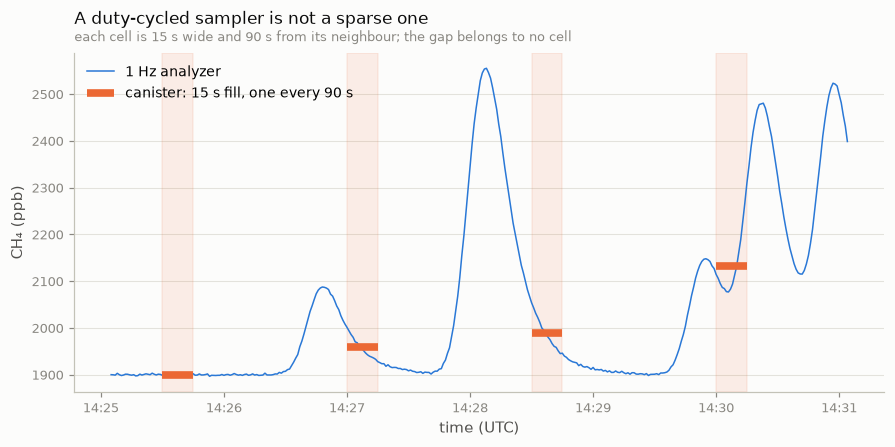

1 Hz samples overlapping each 15 s fill : [16]
canister value vs the 1 Hz mean of exactly those seconds:
   median |difference| 0.40 ppb   worst 1.14 ppb


In [7]:
t_can, v_can, can_win = clip(can, "can_ch4")
can_start, can_stop = bounds_of(can_win)

fig, ax = plt.subplots(figsize=(9.5, 4.0))
ax.plot(t_fast, v_fast, color=C1, lw=1.0, label="1 Hz analyzer")
ax.hlines(v_can, can_start, can_stop, color=C2, lw=5.0, label="canister: 15 s fill, one every 90 s")
for start, stop in zip(can_start, can_stop, strict=True):
    ax.axvspan(start, stop, color=C2, alpha=0.10)
finish(
    ax,
    "A duty-cycled sampler is not a sparse one",
    "each cell is 15 s wide and 90 s from its neighbour; the gap belongs to no cell",
    "CH₄ (ppb)",
    "time (UTC)",
    legend=True,
    loc="upper left",
)
hhmm(ax)
plt.show()

onto_canister = bin_onto_cells(fast_cells, fast["ch4"].values, cells_of(can))
agreement = np.abs(onto_canister.values - can["can_ch4"].values)
print(f"1 Hz samples overlapping each 15 s fill : {np.unique(onto_canister.n_source)}")
print("canister value vs the 1 Hz mean of exactly those seconds:")
print(
    f"   median |difference| {np.nanmedian(agreement):.2f} ppb"
    f"   worst {np.nanmax(agreement):.2f} ppb"
)

Sixteen one-second cells overlap a fifteen-second fill: fourteen wholly inside
it, and a half-cell at each edge where the 1 Hz cells straddle the boundary,
each weighted by how much of it falls in. The canister's value and the 1 Hz
mean of exactly those seconds agree to within the two instruments' noise, which
is the claim the interval model exists to make checkable.

Without bounds there is no way to state which seconds those were. The real
canisters in the archive declare all three of start, stop and mid; TSARA reads
the two it needs and never guesses which column they are (`METHODS.md` §10.6).

---
## 5. How TSARA learns a support, and how it says so

There are four ways an answer can arrive, and they are ranked. The rung is
recorded **per field** — label, width and method separately — because the three
are established independently, and a stream that knows its width exactly may
know nothing about its label.

| rung | meaning |
|---|---|
| `reported` | per-row boundary columns in the file itself |
| `declared` | the manifest states it |
| `inferred` | TSARA read it from the file: column names, measured cadence |
| `assumed` | nothing said; a default applied and labelled |

The exporter can write the same campaign all three ways, so the ladder can be
walked end to end without a real archive.

In [8]:
for declaration in ("reported", "declared", "none"):
    manifest_path = export_raw(data, WORK / f"rung_{declaration}", support_declaration=declaration)
    stream = ingest_campaign(load_manifest(manifest_path))["minute"]
    columns = list(pd.read_csv(manifest_path.parent / "raw" / "minute.csv", nrows=0).columns)
    first = stream["time_bnds"].values[0]
    print(f"support_declaration = {declaration!r}")
    print(f"   raw columns : {columns}")
    print(
        f"   label  {stream.attrs['tsara_support_label']:<8} from "
        f"{stream.attrs['tsara_support_label_source']}"
    )
    print(
        f"   width  {stream.attrs['tsara_nominal_cell_width_s']:<8.0f} from "
        f"{stream.attrs['tsara_support_width_source']}"
    )
    print(
        f"   method {stream['minute_ch4'].attrs['cell_methods']:<12} from "
        f"{stream.attrs['tsara_support_method_source']}"
    )
    print(f"   first cell  {pd.Timestamp(first[0]).time()} -> {pd.Timestamp(first[1]).time()}")
    print()

support_declaration = 'reported'
   raw columns : ['time', 'time_stop', 'minute_ch4']
   label  start    from reported
   width  60       from reported
   method time: mean   from declared
   first cell  14:00:00 -> 14:01:00

support_declaration = 'declared'
   raw columns : ['time', 'minute_ch4']
   label  start    from declared
   width  60       from declared
   method time: mean   from declared
   first cell  14:00:00 -> 14:01:00



support_declaration = 'none'
   raw columns : ['time', 'minute_ch4']
   label  unknown  from assumed
   width  60       from inferred
   method time: point  from assumed
   first cell  13:59:30 -> 14:00:30



Three things in that output are worth reading twice.

**The `reported` file carries a `time_stop` column** and the manifest names it.
That is the only rung where widths are exact per row, which is what a canister
whose fills vary between 14 and 16 seconds actually needs.

**The `none` case still gets a width of 60 s, marked `inferred`.** TSARA
measured the cadence rather than refusing to proceed. What it will not do is
guess the label: with nothing to go on, the label is `unknown` and `assumed`,
and the first cell runs from 13:59:30, half a minute before the record starts.
That is the 30-second shift of section 3, visible in the timestamps.

**Method is never inferred.** Measured across all 1122 ICARTT headers, prose in
a comment is the *only* evidence of averaging that exists: not one file carries
a dispersion column or a sample-count column (`METHODS.md` §10.6). So an
undeclared method is `point` and marked `assumed`, which claims less than the
data supports rather than more.

---
## 6. Binning one stream onto another's cells

This is the primitive the whole model exists for, and the one Phase 4 will
build pairing on. Each target cell receives the mean of the source values that
overlap it, each weighted by *how much* of it falls inside. Nothing is
interpolated: a target cell with no overlapping data comes back as `nan` rather
than as a guess from its neighbours.

Run over the whole hour, the 1 Hz stream binned onto the minute instrument's
cells should reproduce what that instrument published.

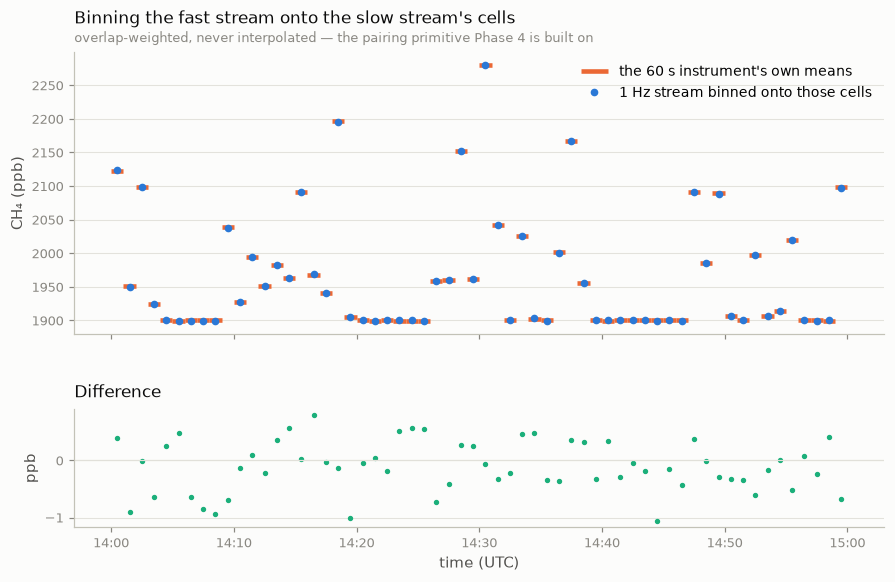

1 Hz cells contributing to each minute : [60 61]
coverage of each minute cell           : 0.9917 to 1.0000
difference from the published means    : rms 0.46 ppb


In [9]:
binned = bin_onto_cells(fast_cells, fast["ch4"].values, cells_of(minute))
own = minute["minute_ch4"].values

fig, axes = plt.subplots(
    2, 1, figsize=(9.5, 5.6), sharex=True, gridspec_kw={"hspace": 0.38, "height_ratios": [2.4, 1]}
)
all_start, all_stop = bounds_of(minute)
axes[0].hlines(own, all_start, all_stop, color=C2, lw=3.0, label="the 60 s instrument's own means")
axes[0].plot(
    minute["time"].values,
    binned.values,
    "o",
    color=C1,
    ms=4.0,
    label="1 Hz stream binned onto those cells",
)
finish(
    axes[0],
    "Binning the fast stream onto the slow stream's cells",
    "overlap-weighted, never interpolated — the pairing primitive Phase 4 is built on",
    "CH₄ (ppb)",
    legend=True,
)
axes[1].plot(minute["time"].values, binned.values - own, ".", color=C3, ms=5)
axes[1].axhline(0, color=GRID, lw=0.8)
finish(axes[1], "Difference", None, "ppb", "time (UTC)")
hhmm(axes[1])
plt.show()

rms = np.sqrt(np.nanmean((binned.values - own) ** 2))
print(f"1 Hz cells contributing to each minute : {np.unique(binned.n_source)}")
print(
    f"coverage of each minute cell           : "
    f"{binned.coverage.min():.4f} to {binned.coverage.max():.4f}"
)
print(f"difference from the published means    : rms {rms:.2f} ppb")

Sixty-one one-second cells contribute to each minute: fifty-nine wholly inside,
plus a half-cell at each edge where the 1 Hz cells straddle it. The exception is
the last minute of the record, which gets sixty and a coverage of 0.9917,
because the fast instrument stopped half a second before the minute did — which
is what `coverage` is for. It is the difference between "no data here" and
"data here, but not all of it".

The residual is not zero, and it is worth being clear about why. Two independent
things contribute: the two instruments drew their measurement noise separately,
and the fast instrument only ever sampled sixty instants of the minute, while
the minute instrument averaged the continuous truth over all of it. The second
is a real limit of the fast record, not an artifact of binning — no arithmetic
recovers what was never sampled.

---
## 7. One operation you must never perform

Cells are a coordinate, and most array tooling does not know that. `resample`,
`coarsen` and `rolling` will happily average a stream and leave the bounds
behind, and the failure is silent: the file keeps a `bounds` attribute pointing
at a variable that no longer exists.

In [10]:
stream = ingest_campaign(load_manifest(declared_manifest))["minute"]
print("before:  time.attrs['bounds'] =", stream["time"].attrs.get("bounds"))
print("         time_bnds present    =", "time_bnds" in stream.variables)

resampled = stream.resample(time="5min").mean()
print("after :  time.attrs['bounds'] =", resampled["time"].attrs.get("bounds"))
print("         time_bnds present    =", "time_bnds" in resampled.variables)

try:
    check_bounds_intact(resampled)
except TsaraSupportError as exc:
    print()
    print("check_bounds_intact:", exc)

before:  time.attrs['bounds'] = time_bnds
         time_bnds present    = True
after :  time.attrs['bounds'] = time_bnds
         time_bnds present    = False

check_bounds_intact: The time coordinate names 'time_bnds' as its bounds variable, but no such variable is present. This is what an xarray resample/coarsen leaves behind; use TSARA's bounds-aware binning instead.


Nothing raised until TSARA was asked. The five-minute means look like a
perfectly ordinary dataset; they simply no longer say what interval any of
their values describes, and the dangling attribute would mislead a CF reader
into looking for a variable that is gone.

`check_bounds_intact` is what turns that into a failure, and TSARA's own
binning is bounds-aware, which is why section 6 used `bin_onto_cells` rather
than a resample.

---
## 8. A clock offset is not a support

Two things can be wrong with a timestamp, and conflating them is easy. Support
says *what interval of air* a value describes. Offset says *when that air was at
the inlet* — the analyzer's clock is fast, or the sample took nine seconds to
travel down the tube. They compose rather than substitute: a cell can be
correctly six seconds wide and still sitting in the wrong place.

On the campaign this package was built for, the offsets measured upstream run
from one to fourteen seconds, while label ambiguity on 1 s data is at most half
a second. **The offset is the larger error, and TSARA had no word for it before
this phase.** `InstrumentConfig.time_shift` is that word. It is declared, not
estimated — deriving one by cross-correlation is a named future avenue — and
what was applied is recorded, so a second correction is visible rather than
silently doubled.

In [11]:
lagged_manifest = export_raw(
    data, WORK / "lagged", support_declaration="declared", time_shift={"minute": "-9s"}
)
lagged = ingest_campaign(load_manifest(lagged_manifest))["minute"]

on_disk = pd.read_csv(lagged_manifest.parent / "raw" / "minute.csv", parse_dates=["time"])
first_start, first_stop = lagged["time_bnds"].values[0]
print(f"first timestamp on disk    : {on_disk['time'].iloc[0].time()}")
print(f"declared correction        : {lagged.attrs['tsara_time_shift']}")
start, stop = pd.Timestamp(first_start).time(), pd.Timestamp(first_stop).time()
print(f"first cell after ingestion : {start} -> {stop}")
print(f"cell width, unchanged      : {(first_stop - first_start).astype('timedelta64[s]')}")

first timestamp on disk    : 14:00:09
declared correction        : -9s
first cell after ingestion : 14:00:00 -> 14:01:00
cell width, unchanged      : 60 seconds


The correction moved the timestamp **and both boundaries** by the same nine
seconds and left the width alone, which is the arithmetic that says offset and
support are different quantities: an offset slides a cell, it does not resize
one.

---
## 9. Cells survive the round trip to disk

Every stage product gets save and load in the phase that introduces it, so the
cells have to reach a file and come back unchanged. The bundle format was
bumped for this phase; a bundle written before cells existed is migrated on
load rather than refused, and marked as the assumption it is.

In [12]:
from tsara.ingest import load_streams, save_streams

# Deliberately the UNDECLARED campaign: the stream that knows least about its
# own cells is the one a load must not quietly improve.
save_streams(ingest_campaign(load_manifest(undeclared_manifest)), WORK / "bundle")
reloaded = load_streams(WORK / "bundle")["minute"]
original = ingest_campaign(load_manifest(undeclared_manifest))["minute"]

same_bounds = np.array_equal(reloaded["time_bnds"].values, original["time_bnds"].values)
methods = reloaded["minute_ch4"].attrs["cell_methods"]
print(f"cell boundaries identical after save and load : {same_bounds}")
print(f"cell_methods preserved                        : {methods}")
for field in ("label", "width", "method"):
    key = f"tsara_support_{field}_source"
    print(f"{key:<34}: {original.attrs[key]} -> {reloaded.attrs[key]}")

cell boundaries identical after save and load : True
cell_methods preserved                        : time: point
tsara_support_label_source        : assumed -> assumed
tsara_support_width_source        : inferred -> inferred
tsara_support_method_source       : assumed -> assumed


That last check is not decoration, and the stream chosen for it is the one that
declared nothing. A save-and-load cycle was found, during this phase's own
review, to **promote** such a stream up the provenance ladder: an absent bounds
variable means two different things at the two bundle versions, and the loader
was migrating unconditionally, so a stream that could not know its cells came
back claiming it had inferred them. Provenance that improves by being written
to disk is provenance nobody should trust, and `assumed -> assumed` above is
the assertion that would have failed.

---
## 10. Uncertainty at a support: recorded, not applied

An instrument specification states a precision at one interval — "0.4 ppb at
1 s" — and the product is a one-minute mean. Reading that figure as if it
described the minute overstates the noise; dividing it by the square root of
sixty understates it, usually badly.

TSARA's manifest can say what interval a figure was quoted at, with
`at_width`. What ingestion does with it is **nothing**, deliberately, and that
was the largest decision of this phase.

In [13]:
spec = load_manifest(declared_manifest).model_dump(mode="json", exclude_none=True)
uncertainty = spec["instruments"]["minute"]["variables"]["minute_ch4"]["uncertainty"]
uncertainty["random"]["at_width"] = "1s"
uncertainty["decorrelation_timescale"] = "30s"

quoted = ingest_campaign(Manifest.model_validate(spec))["minute"]
attrs = quoted["minute_ch4"].attrs
print()
print(f"sigma as declared, per point : {float(quoted['sigma_rand_minute_ch4'].values[0]):.3f} ppb")
print(f"uncertainty_at_width         : {attrs['uncertainty_at_width']}")
print(f"uncertainty_at_width_ratio   : {attrs['uncertainty_at_width_ratio']:.0f}")
print(f"anything rescaled?           : {'uncertainty_n_eff' in attrs}")

2026-09-15 16:11:19 | WARNING  | tsara.ingest.uncertainty | <work>/declared/raw/minute.csv: 'minute_ch4' declares its uncertainty at 1s, but its cells are 60 times that interval. The figures are stored exactly as declared. Moving them onto another support needs a decorrelation timescale and is done by the stage that needs it (METHODS 3.4, 10.8), not at ingestion.



sigma as declared, per point : 0.400 ppb
uncertainty_at_width         : 1s
uncertainty_at_width_ratio   : 60
anything rescaled?           : False


The warning names the variable and says where the arithmetic belongs. The
figure itself is stored exactly as declared, and two attributes record what it
describes: the interval it was quoted at, and how many of those intervals fit
in a cell — the *N* of `METHODS.md` §3.4, and emphatically not N_eff.

Why not just do the division? Because it needs a decorrelation timescale, and
how much averaging helps depends entirely on it.

In [14]:
quoted_interval, cell = 1.0, 60.0
print(f"a sigma quoted at {quoted_interval:.0f} s, on {cell:.0f} s cells\n")
print(f"{'tau':>8}  {'N_eff':>7}  {'sigma falls by':>15}  {'root-N would claim':>19}")
for tau in (1e-9, 5.0, 20.0, 30.0, 300.0):
    rho = np.exp(-quoted_interval / tau)
    n = cell / quoted_interval
    n_eff = np.clip(n * (1 - rho) / (1 + rho), 1.0, n)
    label = "0" if tau < 1e-6 else (f"{tau:.0f} s" if tau < 60 else f"{tau / 60:.0f} min")
    print(f"{label:>8}  {n_eff:7.2f}  {np.sqrt(n_eff):14.2f}x  {np.sqrt(n):18.2f}x")

a sigma quoted at 1 s, on 60 s cells

     tau    N_eff   sigma falls by   root-N would claim
       0    60.00            7.75x                7.75x
     5 s     5.98            2.45x                7.75x
    20 s     1.50            1.22x                7.75x
    30 s     1.00            1.00x                7.75x
   5 min     1.00            1.00x                7.75x


At a 20-second timescale the naive answer is over six times too confident, and
at five minutes the averaging buys nothing whatever. So the correction can be
neither skipped nor guessed — and τ is not a number most data owners have. No
file in the archive declares one; establishing it for an instrument is a
measurement in its own right.

A field that usually cannot be filled honestly must not be what decides whether
a stored number is right. So ingestion records the declaration and the stage
that actually wants a sigma at some support does the arithmetic, in one step,
from the quotation to the support it needs. Estimating τ from the data is a
named future avenue (`METHODS.md` §7); doing it well on plume-dense records,
where there is no quiet stretch to measure against, is the interesting part.

---
## 11. What is real here, and what is invented

| | |
|---|---|
| **Invented** | every number above. Three instruments, one source, one hour, seed 7. |
| **Real** | the *shapes*: 60 s start-labelled means, a 15 s duty-cycled sampler, a 1 s point analyzer. All three are instruments in the campaign archive. |
| **Real** | every measured claim quoted in the prose, each with a `METHODS.md` §10 pointer: the 23.3-day cell the rejected width rule would have produced, the 700/402 split on label evidence, the absence of any dispersion or sample-count column in 1122 files. |
| **Not modelled** | instrument response and cavity residence, which smear a real reading over seconds beneath the cell; a canister's non-uniform fill; the spatial extent of a cell on a moving vehicle. All three are recorded as limits in `METHODS.md` §10.10, not silently assumed away. |
| **Deferred** | moving an uncertainty onto another support, which needs τ; estimating τ; peak-area integration, which the cell-mean ratio does not need, since the width cancels inside every pair. |

The single sentence the phase reduces to:

> **TSARA never evaluates a value on a finer support than it was delivered on.**

Everything above is the bookkeeping that makes that checkable.